In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
print("=== Step 1: Loading Dataset ===")
try:
    df = pd.read_csv('network_traffic.csv', nrows=100000)
    print("Dataset subset loaded successfully.")
except FileNotFoundError:
    print("Dataset file 'network_traffic.csv' not found.")
    print("Generating structured security data with learnable attack patterns...")
    np.random.seed(42)
    n_samples = 1000
    labels = np.random.choice(['BENIGN', 'DDoS', 'Brute-Force'], size=n_samples, p=[0.7, 0.2, 0.1])
    ports = []
    durations = []
    fwd_pkts = []
    bwd_pkts = []
    protocols = []
    for label in labels:
        if label == 'BENIGN':
            ports.append(np.random.choice([80, 443, 8080, 22]))
            durations.append(np.random.randint(1000, 50000))
            fwd_pkts.append(np.random.randint(5, 30))
            bwd_pkts.append(np.random.randint(5, 30))
            protocols.append('TCP')
        elif label == 'DDoS':
            ports.append(80)
            durations.append(np.random.randint(1, 500))
            fwd_pkts.append(np.random.randint(500, 5000)) 
            bwd_pkts.append(np.random.randint(0, 2)) 
            protocols.append('UDP')
        elif label == 'Brute-Force':
            ports.append(22) 
            durations.append(np.random.randint(50, 200))
            fwd_pkts.append(np.random.randint(1, 4))
            bwd_pkts.append(np.random.randint(1, 4))
            protocols.append('TCP')
    df = pd.DataFrame({
        'Destination_Port': ports,
        'Flow_Duration': durations,
        'Total_Fwd_Packets': fwd_pkts,
        'Total_Backward_Packets': bwd_pkts,
        'Protocol_Type': protocols,
        'Label': labels
    })

=== Step 1: Loading Dataset ===
Dataset file 'network_traffic.csv' not found.
Generating structured security data with learnable attack patterns...


In [23]:
print("=== Step 2: Data Preprocessing ===")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
if 'Protocol_Type' in df.columns:
    encoder = LabelEncoder()
    df['Protocol_Type'] = encoder.fit_transform(df['Protocol_Type'])
X = df.drop('Label', axis=1)
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

=== Step 2: Data Preprocessing ===


In [24]:
print("=== Step 3: Training Cost-Sensitive Classifier ===")
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train_scaled, y_train)
print("Model training complete.")

=== Step 3: Training Cost-Sensitive Classifier ===
Model training complete.


=== Step 4: Evaluating Solution Performance ===
Overall Accuracy: 100.00%
Weighted Precision: 1.00
Weighted Recall: 1.00

Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00       214
 Brute-Force       1.00      1.00      1.00        30
        DDoS       1.00      1.00      1.00        56

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



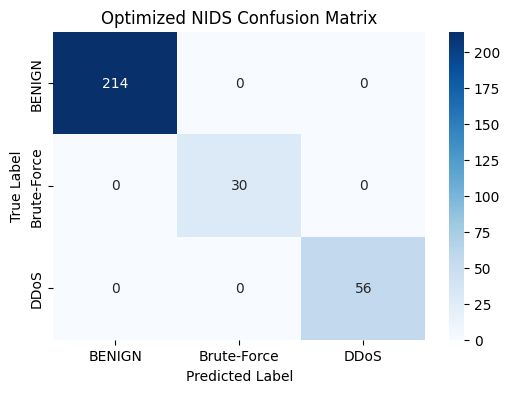

In [25]:
print("=== Step 4: Evaluating Solution Performance ===")
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Overall Accuracy: {acc * 100:.2f}%")
print(f"Weighted Precision: {prec:.2f}")
print(f"Weighted Recall: {rec:.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Optimized NIDS Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()